<a href="https://colab.research.google.com/github/hannahthirsk-ui/Influenza-dashboard/blob/main/riskanddecisonmaking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
!pip install pyagrum

In [22]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import pandas as pd

In [23]:
df = pd.read_csv("/content/student_bn_dataset_50 (1).csv")
df.head()

,Intelligence,Motivation,StudyHours,Sleep,Stress,Grade
0,low,high,high,good,low,good
1,low,high,high,good,high,good
2,high,low,high,good,low,good
3,high,low,low,good,high,poor
4,high,high,low,poor,low,poor


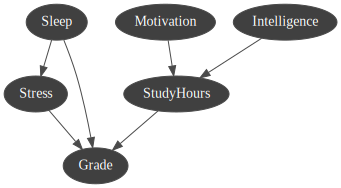

In [24]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb

bn = gum.BayesNet("StudentPerformance")

# add nodes
I = bn.add(gum.LabelizedVariable("Intelligence", "Intelligence", ["low", "high"]))
M = bn.add(gum.LabelizedVariable("Motivation", "Motivation", ["low", "high"]))
SH = bn.add(gum.LabelizedVariable("StudyHours", "StudyHours", ["low", "high"]))
S = bn.add(gum.LabelizedVariable("Sleep", "Sleep", ["poor", "good"]))
ST = bn.add(gum.LabelizedVariable("Stress", "Stress", ["low", "high"]))
G = bn.add(gum.LabelizedVariable("Grade", "Grade", ["poor", "good"]))

# add arcs
bn.addArc(I, SH)
bn.addArc(M, SH)
bn.addArc(S, ST)
bn.addArc(SH, G)
bn.addArc(ST, G)
bn.addArc(S, G)

gnb.showBN(bn)

In [25]:
df = pd.read_csv("/content/student_bn_dataset_50 (1).csv")

if "index" in df.columns:
    df = df.drop(columns=["index"])

df.head()

,Intelligence,Motivation,StudyHours,Sleep,Stress,Grade
0,low,high,high,good,low,good
1,low,high,high,good,high,good
2,high,low,high,good,low,good
3,high,low,low,good,high,poor
4,high,high,low,poor,low,poor


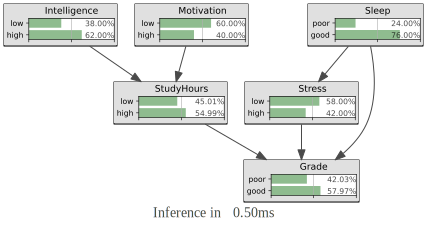

In [26]:
# learn CPTs
learner = gum.BNLearner(df, bn)
bn_trained = learner.learnParameters(bn.dag())

# show trained BN w probabilities
gnb.showInference(bn_trained)

In [27]:
# show conditional probability tables
gnb.sideBySide(
    bn_trained.cpt("Intelligence"),
    bn_trained.cpt("Motivation"),
    bn_trained.cpt("Sleep")
)

gnb.sideBySide(
    bn_trained.cpt("StudyHours"),
    bn_trained.cpt("Stress"),
    bn_trained.cpt("Grade")
)

In [28]:
ie = gum.LazyPropagation(bn_trained)

# no evidence
ie.makeInference()
print("P(Motivation) with no evidence:")
print(ie.posterior("Motivation"))

# evidence: Intelligence = low
ie.setEvidence({"Intelligence": "low"})
ie.makeInference()
print("P(Motivation | Intelligence = low):")
print(ie.posterior("Motivation"))

# evidence: StudyHours = high
ie.setEvidence({"StudyHours": "high"})
ie.makeInference()
print("P(Motivation | StudyHours = high):")
print(ie.posterior("Motivation"))

# evidence: StudyHours = high and Intelligence = low
ie.setEvidence({"StudyHours": "high", "Intelligence": "low"})
ie.makeInference()
print("P(Motivation | StudyHours = high, Intelligence = low):")
print(ie.posterior("Motivation"))

P(Motivation) with no evidence:

  Motivation       |
low      |high     |
---------|---------|
 0.6000  | 0.4000  |

P(Motivation | Intelligence = low):

  Motivation       |
low      |high     |
---------|---------|
 0.6000  | 0.4000  |

P(Motivation | StudyHours = high):

  Motivation       |
low      |high     |
---------|---------|
 0.4936  | 0.5064  |

P(Motivation | StudyHours = high, Intelligence = low):

  Motivation       |
low      |high     |
---------|---------|
 0.3418  | 0.6582  |



In [29]:
ie = gum.LazyPropagation(bn_trained)

ie.setEvidence({
    "Intelligence": "high",
    "Motivation": "low",
    "Sleep": "poor"
})

ie.makeInference()

print("P(Grade | Intelligence=high, Motivation=low, Sleep=poor):")
print(ie.posterior("Grade"))

P(Grade | Intelligence=high, Motivation=low, Sleep=poor):

  Grade            |
poor     |good     |
---------|---------|
 0.5529  | 0.4471  |



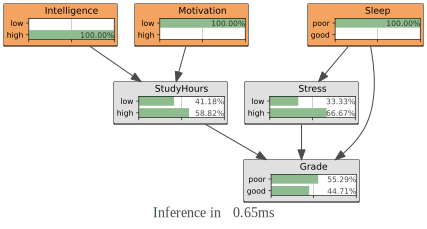

In [30]:
gnb.showInference(
    bn_trained,
    evs={
        "Intelligence": "high",
        "Motivation": "low",
        "Sleep": "poor"
    }
)

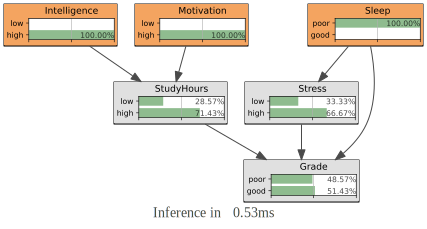

In [31]:
# scenario 1: higher motivation
gnb.showInference(
    bn_trained,
    evs={
        "Intelligence": "high",
        "Motivation": "high",
        "Sleep": "poor"
    }
)

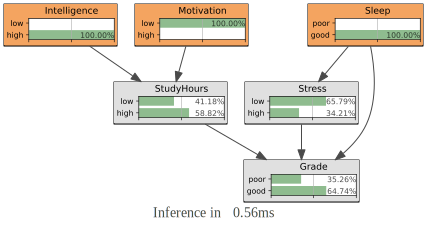

In [32]:
# scenario 2: better sleep
gnb.showInference(
    bn_trained,
    evs={
        "Intelligence": "high",
        "Motivation": "low",
        "Sleep": "good"
    }
)

In [34]:
ie = gum.LazyPropagation(bn_trained)

# scenario 1: motivation changed to high
ie.setEvidence({
    "Intelligence": "high",
    "Motivation": "high",
    "Sleep": "poor"
})
ie.makeInference()
print("Scenario 1: P(Grade | Intelligence=high, Motivation=high, Sleep=poor)")
print(ie.posterior("Grade"))

# scenario 2: sleep changed to good
ie.setEvidence({
    "Intelligence": "high",
    "Motivation": "low",
    "Sleep": "good"
})
ie.makeInference()
print("Scenario 2: P(Grade | Intelligence=high, Motivation=low, Sleep=good)")
print(ie.posterior("Grade"))

Scenario 1: P(Grade | Intelligence=high, Motivation=high, Sleep=poor)

  Grade            |
poor     |good     |
---------|---------|
 0.4857  | 0.5143  |

Scenario 2: P(Grade | Intelligence=high, Motivation=low, Sleep=good)

  Grade            |
poor     |good     |
---------|---------|
 0.3526  | 0.6474  |



In [35]:
# stress = high
bn_high_stress = gum.BayesNet(bn_trained)
bn_high_stress.eraseArc("Sleep", "Stress")     # remove cause of stress
bn_high_stress.cpt("Stress").fillWith([0, 1])  # low=0, high=1

ie1 = gum.LazyPropagation(bn_high_stress)
ie1.setEvidence({
    "Intelligence": "high",
    "Motivation": "high"
})
ie1.makeInference()

print("Stress set to high:")
print(ie1.posterior("Grade"))


# stress = low
bn_low_stress = gum.BayesNet(bn_trained)
bn_low_stress.eraseArc("Sleep", "Stress")      # remove cause of stress
bn_low_stress.cpt("Stress").fillWith([1, 0])   # low=1, high=0

ie2 = gum.LazyPropagation(bn_low_stress)
ie2.setEvidence({
    "Intelligence": "high",
    "Motivation": "high"
})
ie2.makeInference()

print("Stress set to low:")
print(ie2.posterior("Grade"))


# compare good grade probabilities
p_high_stress = ie1.posterior("Grade")[{"Grade": "good"}]
p_low_stress = ie2.posterior("Grade")[{"Grade": "good"}]

print("P(good grade when stress is high) =", round(p_high_stress, 4))
print("P(good grade when stress is low) =", round(p_low_stress, 4))
print("Difference =", round(p_low_stress - p_high_stress, 4))

Stress set to high:

  Grade            |
poor     |good     |
---------|---------|
 0.3757  | 0.6243  |

Stress set to low:

  Grade            |
poor     |good     |
---------|---------|
 0.3224  | 0.6776  |

P(good grade when stress is high) = 0.6243
P(good grade when stress is low) = 0.6776
Difference = 0.0533


In [36]:
import pandas as pd

songs = pd.read_csv("/content/song_success_20 (1).csv")
songs

,Song ID,Reached 1 million plays,Model Prediction P(Success = Yes)
0,S01,No,0.25
1,S02,Yes,0.60
2,S03,Yes,0.95
3,S04,No,0.55
4,S05,No,0.05
5,S06,Yes,0.70
6,S07,No,0.25
7,S08,Yes,0.90
8,S09,Yes,0.40
9,S10,Yes,0.85


In [37]:
thresholds = [0.1, 0.5, 0.7, 0.9]

for t in thresholds:
    print("Threshold:", t)

    pred_yes = songs["Model Prediction P(Success = Yes)"] >= t
    true_yes = songs["Reached 1 million plays"] == "Yes"

    tp = (pred_yes & true_yes).sum()
    fp = (pred_yes & ~true_yes).sum()
    tn = (~pred_yes & ~true_yes).sum()
    fn = (~pred_yes & true_yes).sum()

    table = pd.DataFrame(
        {
            f"Predicted success yes < {t}": [tn, fn],
            f"Predicted success yes ≥ {t}": [fp, tp]
        },
        index=["True success = No", "True success = Yes"]
    )

    display(table)
    print()

Threshold: 0.1


,Predicted success yes < 0.1,Predicted success yes ≥ 0.1
True success = No,1,9
True success = Yes,0,10



Threshold: 0.5


,Predicted success yes < 0.5,Predicted success yes ≥ 0.5
True success = No,8,2
True success = Yes,1,9



Threshold: 0.7


,Predicted success yes < 0.7,Predicted success yes ≥ 0.7
True success = No,9,1
True success = Yes,5,5



Threshold: 0.9


,Predicted success yes < 0.9,Predicted success yes ≥ 0.9
True success = No,9,1
True success = Yes,7,3


In [38]:
results = []

for t in thresholds:
    pred_yes = songs["Model Prediction P(Success = Yes)"] >= t
    true_yes = songs["Reached 1 million plays"] == "Yes"

    tp = (pred_yes & true_yes).sum()
    fp = (pred_yes & ~true_yes).sum()
    tn = (~pred_yes & ~true_yes).sum()
    fn = (~pred_yes & true_yes).sum()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    accuracy = (tp + tn) / len(songs)

    results.append({
        "Threshold": t,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "Sensitivity": round(sensitivity, 2),
        "Specificity": round(specificity, 2),
        "Accuracy": round(accuracy, 2)
    })

results_df = pd.DataFrame(results)
results_df

,Threshold,TP,FP,TN,FN,Sensitivity,Specificity,Accuracy
0,0.1,10,9,1,0,1.0,0.1,0.55
1,0.5,9,2,8,1,0.9,0.8,0.85
2,0.7,5,1,9,5,0.5,0.9,0.70
3,0.9,3,1,9,7,0.3,0.9,0.60


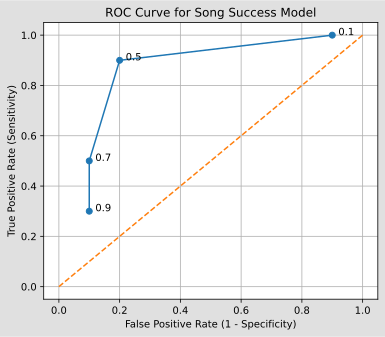

In [39]:
import matplotlib.pyplot as plt

# false positive rate
results_df["FPR"] = 1 - results_df["Specificity"]

# true positive rate
results_df["TPR"] = results_df["Sensitivity"]

plt.figure(figsize=(6, 5))
plt.plot(results_df["FPR"], results_df["TPR"], marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")

for i, row in results_df.iterrows():
    plt.text(row["FPR"] + 0.02, row["TPR"], str(row["Threshold"]))

plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve for Song Success Model")
plt.grid(True)
plt.show()

In [40]:
roc_points = results_df[["Threshold", "FPR", "TPR", "Specificity", "Sensitivity", "Accuracy"]]
roc_points

,Threshold,FPR,TPR,Specificity,Sensitivity,Accuracy
0,0.1,0.9,1.0,0.1,1.0,0.55
1,0.5,0.2,0.9,0.8,0.9,0.85
2,0.7,0.1,0.5,0.9,0.5,0.70
3,0.9,0.1,0.3,0.9,0.3,0.60


In [41]:
import pandas as pd

shift = pd.read_csv("/content/shift_screen_fatigue_1200 (1).csv")
shift.head()

,id,shift,screen_high,fatigue
0,1,Day,1,1
1,2,Day,1,1
2,3,Day,1,1
3,4,Day,1,1
4,5,Day,1,1


In [42]:
shift.columns

Index(['id', 'shift', 'screen_high', 'fatigue'], dtype='object')

In [44]:
# overall fatigue table by screen exposure
overall = pd.crosstab(
    shift["screen_high"],
    shift["fatigue"],
    margins=True
)

overall

fatigue,0,1,All
screen_high,,,
0,450,150,600
1,390,210,600
All,840,360,1200


In [45]:
# risk of fatigue for low screen and high screen
risk_by_screen = shift.groupby("screen_high")["fatigue"].mean()
risk_by_screen

,fatigue
screen_high,
0,0.25
1,0.35


In [46]:
risk_low = risk_by_screen.loc[0]
risk_high = risk_by_screen.loc[1]

absolute_increase = risk_high - risk_low
relative_risk = risk_high / risk_low
relative_increase = relative_risk - 1

print("Risk of fatigue with low screen exposure:", round(risk_low, 4))
print("Risk of fatigue with high screen exposure:", round(risk_high, 4))
print("Absolute increase in risk:", round(absolute_increase, 4))
print("Relative risk:", round(relative_risk, 4))
print("Relative increase:", round(relative_increase, 4))

Risk of fatigue with low screen exposure: 0.25
Risk of fatigue with high screen exposure: 0.35
Absolute increase in risk: 0.1
Relative risk: 1.4
Relative increase: 0.4


In [47]:
# screen exposure by shift
pd.crosstab(shift["screen_high"], shift["shift"])

shift,Day,Night
screen_high,,
0,350,250
1,350,250


In [48]:
# fatigue risk by shift and screen exposure
risk_by_shift_screen = shift.groupby(["shift", "screen_high"])["fatigue"].mean()
risk_by_shift_screen

shift  screen_high
Day    0              0.171429
       1              0.200000
Night  0              0.360000
       1              0.560000
Name: fatigue, dtype: float64

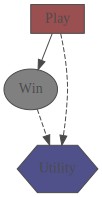

In [49]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb

# create influence diagram
diag = gum.InfluenceDiagram()

# nodes
play = diag.addDecisionNode(gum.LabelizedVariable("Play", "Play", ["No", "Yes"]))
win = diag.addChanceNode(gum.LabelizedVariable("Win", "Win", ["Lose", "Win"]))
utility = diag.addUtilityNode(gum.LabelizedVariable("Utility", "Utility", 1))

# arcs
diag.addArc("Play", "Win")
diag.addArc("Play", "Utility")
diag.addArc("Win", "Utility")

# probabilities for Win
# Win states: Lose, Win
diag.cpt("Win")[{"Play": "No"}] = [1, 0]
diag.cpt("Win")[{"Play": "Yes"}] = [2/3, 1/3]

# utilities
# Not playing gives utility 0
diag.utility("Utility")[{"Play": "No", "Win": "Lose"}] = 0
diag.utility("Utility")[{"Play": "No", "Win": "Win"}] = 0

# Playing costs £4
# Lose: -4
# Win: 15 - 4 = 11
diag.utility("Utility")[{"Play": "Yes", "Win": "Lose"}] = -4
diag.utility("Utility")[{"Play": "Yes", "Win": "Win"}] = 11

# show diagram
gnb.showInfluenceDiagram(diag)

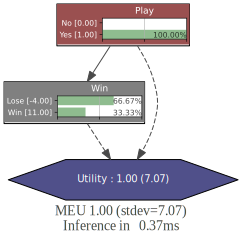

In [50]:
gnb.showInference(diag)